# **Grid World**

### 1. Setup



The grid world is a classic example demonstrating reinforcement learning. An agent must traverse a grid from a starting pixel to an ending pixel while avoiding traps in the most optimal path. In most cases, the optimal path is roughly the shortest path that avoids the risk of falling into traps to some degree. 

In [28]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Simulation

Let us first create the grid world,

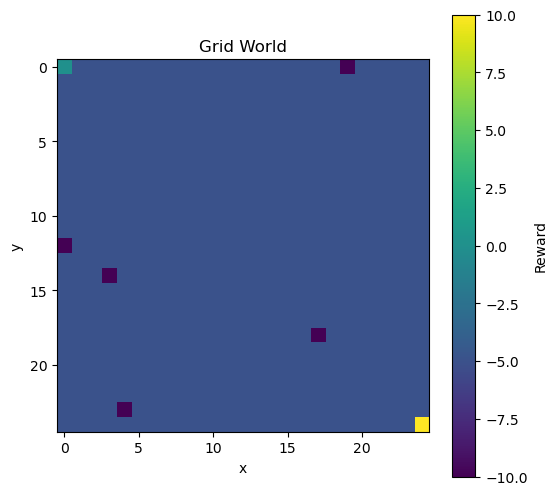

In [70]:
# World settings,
WORLD_SIZE = 25
AGENT_LOC = (0, 0)
GOAL_LOC = (WORLD_SIZE-1, WORLD_SIZE-1)
N_TRAPS = 5
ALPHA = -5

# Initialising grid,
grid = ALPHA*np.ones(shape=(WORLD_SIZE, WORLD_SIZE))

# Creating random traps,
trap_locs = []
for trap in range(N_TRAPS):
    trap_loc = np.random.randint(low=0, high=WORLD_SIZE-1, size=2)
    grid[trap_loc[0], trap_loc[1]] = -np.inf
    trap_locs.append(trap_loc)

# Adding agent and ending locations,
grid[AGENT_LOC] = 0
grid[GOAL_LOC] = np.inf

# Displaying the grid world,
grid_plot = grid.copy()
grid_plot[np.isneginf(grid_plot)] = -10 # Traps
grid_plot[np.isposinf(grid_plot)] = 10  # Goal
plt.figure(figsize=(6, 6))
im = plt.imshow(grid_plot, cmap="viridis")
plt.colorbar(im, label="Reward")
plt.title("Grid World")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Now we create the `Environment` and `Agent` class give us an interface to move the agent across the grid world. The `Environment` handles updating the state of the environment in response to the movement of the agent. We can imagine it as a basic world engine to simulate the environment the agent is in.

In [ ]:
class Environment():

    # Actions,
    ACTIONS = {
        "up": (-1, 0),
        "down": (1, 0),
        "left": (0, -1),
        "right": (0, 1),
    }

    def __init__(self, world_size, alpha, n_traps, goal_loc, agent_loc):

        # Assigning class attributes,
        self.world_size = world_size
        self.alpha = alpha
        self.n_traps = n_traps
        self.goal_loc = goal_loc
        self.agent_loc = agent_loc

        # Creating trap locations,
        trap_locs = []
        for i in range(n_traps):
            trap_loc = np.random.randint(low=0, high=WORLD_SIZE-1, size=2)
            grid[trap_loc[0], trap_loc[1]] = -np.inf
            trap_locs.append(trap_loc)
        self.trap_locs = trap_locs

        # Creating grid world,
        self.grid = self._create_grid_(world_size, alpha, trap_locs, goal_loc, agent_loc)

    def update(self, action):
        """Updates the environment state based on the new location of the agent."""

        # Updating agent location,
        dx, dy = self.ACTIONS[action]
        self.agent_loc[0] += dx
        self.agent_loc[1] += dy

        # Updating environment state,
        reward = self.grid[tuple(self.agent_loc)] # <-- Reward for the agent.
        self.grid = self._create_grid_(self.world_size, self.alpha, self.trap_locs, self.goal_loc, self.agent_loc)

        return self.grid.copy(), reward

    def _create_grid_(self, world_size, alpha, trap_locs, goal_loc, agent_loc):
        """Constructs the environment state given the location of the agent."""

        # Creating grid world,
        grid = alpha*np.ones(shape=(world_size, world_size))

        # Creating random traps,
        for trap_loc in trap_locs:
            grid[tuple(trap_loc)] = -np.inf

        # Adding agent and goal locations,
        grid[tuple(agent_loc)] = 0
        grid[goal_loc] = 100

        return grid

class Agent():

    def __init__(self, env):

        # Assigning class attributes,
        self.env = env
        self.total_reward = 0

    def act(self, action):
        state, reward = self.env.update(action)
        self.total_reward += reward
        return state, reward

The boilerplate code to create the environment,

In [169]:
# World settings,
WORLD_SIZE = 5
AGENT_LOC = [0, 0]
GOAL_LOC = (WORLD_SIZE-1, WORLD_SIZE-1)
N_TRAPS = 5
ALPHA = -5

# Creating agent and environment,
env = Environment(world_size=WORLD_SIZE, alpha=ALPHA, n_traps=N_TRAPS, goal_loc=GOAL_LOC, agent_loc=AGENT_LOC)
agent = Agent(env)